# 07 - DTW on z-normalised data

Notebook 01 ended with this result: `amplitude_scaled` (273.3) scored almost as far
from the reference as `unrelated` (317.3), although it *is* the reference, only twice as
tall. DTW sums real magnitude differences, so any offset or scale between two series is
paid on every aligned pair.

**What we change.** Before running DTW, every series is z-normalised - shifted to mean 0
and divided by its standard deviation. This removes offset and amplitude from the
comparison, so the distance only reflects the *shape* of the signals. Everything else
(dataset, DTW implementation, path-length normalisation) is identical to notebook 01.

In [1]:
import sys
from pathlib import Path

# The notebooks live in `notebooks/`, the packages in the project root.
ROOT = Path.cwd()
if not (ROOT / "data").is_dir():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd

from data.synthetic import generate_dataset
from utils import plotting
from utils.distances import dtw_cost_matrix, dtw_distance, edr_distance, erp_distance

%matplotlib inline
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

## z-normalisation

```
z = (x - mean(x)) / std(x)
```

Each series is normalised with *its own* mean and standard deviation, so the reference
and a variant are scaled independently - that is what makes the comparison invariant to
amplitude.

In [2]:
def z_normalize(x: np.ndarray) -> np.ndarray:
    """Shift ``x`` to mean 0 and scale it to standard deviation 1."""
    return (x - x.mean()) / x.std()


dataset = generate_dataset()
normalized = {name: z_normalize(series) for name, series in dataset.items()}

print(f"{'series':>17}  {'n':>4}  {'raw mean':>9} {'raw std':>8}  {'z mean':>7} {'z std':>6}")
for name in dataset:
    raw, z = dataset[name], normalized[name]
    print(f"{name:>17}  {len(raw):>4}  {raw.mean():>+9.3f} {raw.std():>8.3f}  "
          f"{z.mean():>+7.3f} {z.std():>6.3f}")

           series     n   raw mean  raw std   z mean  z std
        reference   300     +0.442    1.472   -0.000  1.000
 amplitude_scaled   300     +0.885    2.945   -0.000  1.000
        resampled   390     +0.443    1.467   +0.000  1.000
            noisy   300     +0.410    1.574   +0.000  1.000
    phase_shifted   300     +0.566    1.505   -0.000  1.000
         reversed   300     +0.442    1.472   -0.000  1.000
        unrelated   300     +0.869    1.528   +0.000  1.000


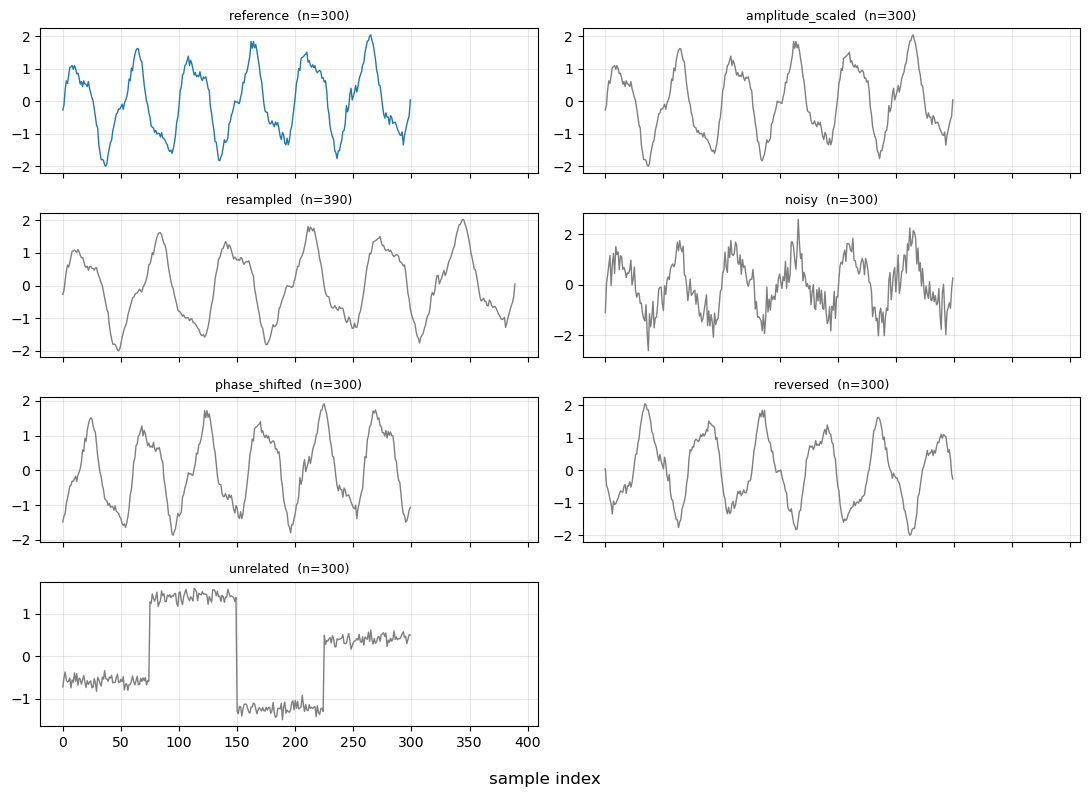

In [3]:
# After normalisation `amplitude_scaled` is indistinguishable from the reference.
plotting.plot_dataset(normalized)

## DTW on the normalised series

In [4]:
reference = normalized["reference"]
variants = [name for name in normalized if name != "reference"]

rows = []
for name in variants:
    D = dtw_cost_matrix(reference, normalized[name])
    rows.append({
        "variant": name,
        "dtw": float(D[-1, -1]),
        "dtw_norm": float(D[-1, -1]) / (len(reference) + len(normalized[name])),
    })

dtw_table = pd.DataFrame(rows).set_index("variant").sort_values("dtw")
dtw_table

,dtw,dtw_norm
variant,,
amplitude_scaled,0.000,0.000
resampled,15.779,0.023
phase_shifted,55.018,0.092
reversed,68.155,0.114
noisy,75.884,0.126
unrelated,221.459,0.369


## Ranking

In [5]:
print("similarity to reference (most similar first)")
print()
for rank, (name, row) in enumerate(dtw_table.iterrows(), start=1):
    print(f"{rank}. {name:<17} dtw = {row['dtw']:>8.3f}   dtw_norm = {row['dtw_norm']:.3f}")

similarity to reference (most similar first)

1. amplitude_scaled  dtw =    0.000   dtw_norm = 0.000
2. resampled         dtw =   15.779   dtw_norm = 0.023
3. phase_shifted     dtw =   55.018   dtw_norm = 0.092
4. reversed          dtw =   68.155   dtw_norm = 0.114
5. noisy             dtw =   75.884   dtw_norm = 0.126
6. unrelated         dtw =  221.459   dtw_norm = 0.369


## EDR and ERP on the normalised series

Same parameters as notebooks 02 and 03, but note what they mean now: after z-normalisation
`eps=0.5` is half a standard deviation of the signal, and the ERP gap value `g=0` is
exactly the mean of every series.

In [6]:
EPS = 0.5  # EDR matching tolerance, in units of the series' standard deviation
G = 0.0    # ERP gap element - the mean of every z-normalised series

edr_erp = pd.DataFrame({
    "EDR": [edr_distance(reference, normalized[v], EPS) for v in variants],
    "ERP": [erp_distance(reference, normalized[v], G) for v in variants],
}, index=pd.Index(variants, name="variant"))
edr_erp.sort_values("ERP")

,EDR,ERP
variant,,
amplitude_scaled,0.000,0.000
noisy,61.000,80.002
resampled,90.000,80.525
phase_shifted,80.000,96.049
reversed,118.000,136.422
unrelated,211.000,268.545


## All results side by side

In [7]:
# Distances and per-method ranks (1 = most similar) on the z-normalised data.
comparison = pd.DataFrame({
    "DTW": [dtw_distance(reference, normalized[v]) for v in variants],
    "EDR": edr_erp["EDR"],
    "ERP": edr_erp["ERP"],
}, index=edr_erp.index)
ranks = comparison.rank().astype(int).add_suffix(" rank")

pd.concat([comparison, ranks], axis=1).sort_values("DTW")

,DTW,EDR,ERP,DTW rank,EDR rank,ERP rank
variant,,,,,,
amplitude_scaled,0.000,0.000,0.000,1,1,1
resampled,15.779,90.000,80.525,2,4,3
phase_shifted,55.018,80.000,96.049,3,3,4
reversed,68.155,118.000,136.422,4,5,5
noisy,75.884,61.000,80.002,5,2,2
unrelated,221.459,211.000,268.545,6,6,6


## Conclusion

- z-normalisation makes all three measures **amplitude-invariant**: `amplitude_scaled`
  scores exactly 0 for DTW, EDR and ERP, and `unrelated` is last everywhere.
- The **middle of the ranking is where the methods still disagree**. DTW keeps
  `resampled` closest (15.8), while EDR and ERP now put `noisy` first (61 / 80.0): with
  `eps` and `g` expressed in standard deviations, the extra noise mostly stays inside the
  tolerance band, whereas a 30 % stretch still costs 90 inserted samples.
- Normalisation removes offset and scale, nothing else - `reversed` and `unrelated` are
  as far away as before. Use it when gain and baseline are not part of the question;
  skip it when an amplitude change *is* the anomaly.